In [1]:
from matplotlib.colors import ListedColormap
import torch
import nrrd 
import copy
import matplotlib.pyplot as plt
import numpy as np
import torchvision.models as models 
from torch.utils.data import Dataset,DataLoader,WeightedRandomSampler
from model.LeNet5 import LeNet
import numpy as np
import os
from PIL import Image, ImageOps
from torchvision import transforms
from pathlib import Path
from typing import Dict, Optional
import re
from torch.utils.data import random_split
from collections import Counter
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm
import torch.optim as optim
import wandb
from sklearn.metrics import confusion_matrix, classification_report,f1_score,balanced_accuracy_score

In [2]:
#Global variable
pattern=re.compile(r"^Segment(\d+)_Tags$")
Segment_signal_string="Segmentation.Status:inprogress"
label_type={'binh_thuong':0,
            'dut_ban_phan_1_3_giua':1,
            'dut_hoan_toan_1_3_giua':2,
            'dut_ban_phan_1_3_duoi':3,
            'dut_hoan_toan_1_3_duoi':4,
            'dut_ban_phan_1_3_tren':5,
            'dut_hoan_toan_1_3_tren':6
            }
sweep_config={
    'method':'random',
    'metric':{
        'name':'val_weighted_f1',
        'goal':'maximize'
    },
    'parameters':{
        'lr':{
            'values':[1e-3,1e-4,5e-4]
        },
        'epoch':{
            'values':[30,40,50]
        },
        'batch_size':{
            'values':[4,8,16]
        }
    }
}

Scanning folder: 2025_14_11_Thanh
Number of selected files: 19
Scanning folder: 2025_22_11_Thuan
Number of selected files: 20
Scanning folder: 2026_18_1_Thuan
Number of selected files: 16
Scanning folder: 2026_1_2_Thanh
Number of selected files: 20
Scanning folder: 26_01_02_Thanh
Number of selected files: 22
Scanning folder: 26_16_02_Thuan
Number of selected files: 52
Scanning folder: 26_27_02_Thanh
Number of selected files: 20

ACL type distribution:
Total patient: 169
dut_ban_phan_1_3_giua: 30
dut_hoan_toan_1_3_giua: 29
dut_ban_phan_1_3_duoi: 17
dut_hoan_toan_1_3_tren: 32
dut_ban_phan_1_3_tren: 21
binh_thuong: 37
segment_1: 3


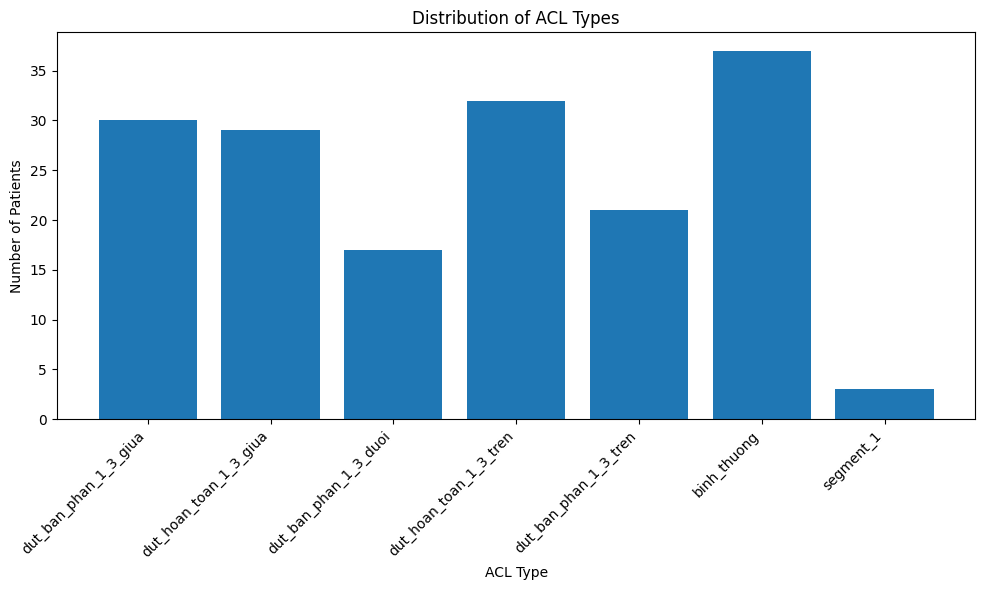

In [3]:
class ACLDataCollector:
    def __init__(
        self,
        root_dir: str,
        pattern: str,
        segment_signal_string: str,
        image_keyword: str = "t2_tse_sag",
        seg_keyword: str = "Segmentation*.seg.nrrd",
    ):
        self.root_dir = Path(root_dir)
        self.pattern = re.compile(pattern)
        self.segment_signal_string = segment_signal_string
        self.image_keyword = image_keyword.lower()
        self.seg_keyword = seg_keyword
        self.all_patients: Dict[str, Dict] = {}
        self.type_count: Dict[str, int] = {}

    def get_acl_indices(self, seg_header: dict):
        seg_indices = []
        for k in seg_header.keys():
            m = self.pattern.match(k)
            if m:
                seg_indices.append(m.group(1))
        return seg_indices

    def get_acl_type(self, seg_header: Dict) -> Optional[str]:
        indices = self.get_acl_indices(seg_header)
        for idx in indices:
            tag_key = f"Segment{idx}_Tags"
            name_key = f"Segment{idx}_Name"

            if tag_key in seg_header and name_key in seg_header:
                value = str(seg_header[tag_key])
                if value.startswith(self.segment_signal_string):
                    return str(seg_header[name_key]).lower()
        return None

    def collect_data_and_seg(self, folder_path: Path) -> Dict:
        result = {}
        for subfolder in folder_path.iterdir():
            if not subfolder.is_dir():
                continue
            seg_files = sorted(subfolder.glob(self.seg_keyword))
            t2_files = sorted(
                p for p in subfolder.glob("*.nrrd")
                if self.image_keyword in p.stem.lower()
            )
            if not seg_files or not t2_files:
                continue
            _, seg_header = nrrd.read(str(seg_files[0]))
            acl_type = self.get_acl_type(seg_header)

            result[subfolder.name] = {
                "nrrd": str(t2_files[0]),
                "seg": str(seg_files[0]),
                "type": acl_type,
            }
        return result
    def collect_all(self) -> Dict:
        self.all_patients = {}
        for sub_folder in self.root_dir.iterdir():
            if not sub_folder.is_dir():
                continue
            print(f"Scanning folder: {sub_folder.name}")
            data_dict = self.collect_data_and_seg(sub_folder)
            self.all_patients.update(data_dict)
            print(f"Number of selected files: {len(data_dict)}")
        return self.all_patients

    def count_acl_types(self) -> Dict[str, int]:
        self.type_count = {}
        for _, data in self.all_patients.items():
            acl_type = data["type"] if data["type"] is not None else "unknown"
            self.type_count[acl_type] = self.type_count.get(acl_type, 0) + 1
        return self.type_count
    
    def print_summary(self):
        if not self.type_count:
            self.count_acl_types()
        print("\nACL type distribution:")
        print(f"Total patient: {len(self.all_patients)}")
        for k, v in self.type_count.items():
            print(f"{k}: {v}")

    def plot_distribution(self):
        if not self.type_count:
            self.count_acl_types()

        labels = list(self.type_count.keys())
        counts = list(self.type_count.values())

        plt.figure(figsize=(10, 6))
        plt.bar(labels, counts)
        plt.xlabel("ACL Type")
        plt.ylabel("Number of Patients")
        plt.title("Distribution of ACL Types")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
 
    collector = ACLDataCollector(
        root_dir=r"D:\Project\ACL\my_tool\data",
        pattern=pattern,
        segment_signal_string=Segment_signal_string
    )

    all_patients=collector.collect_all()
    collector.count_acl_types()
    collector.print_summary()
    collector.plot_distribution()

In [4]:
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset
import nrrd
from typing import Dict

class MRI_data(Dataset):
    def __init__(
        self,
        data_dict: Dict,
        img_transform=None,
        label_transform=None,
        target_size=(320, 320),
        target_depth=8,
    ):
        self.data_dict = data_dict
        self.img_transform = img_transform
        self.label_transform = label_transform
        self.target_size = target_size
        self.target_depth = target_depth
        self.samples = []

        num_patient = 0

        for patient, data in data_dict.items():
            nrrd_path = data["nrrd"]
            seg_path = data["seg"]

            nrrd_data, _ = nrrd.read(nrrd_path)
            seg_data, _ = nrrd.read(seg_path)

            type_acl = data["type"]

            # Skip wrong label
            if type_acl == "segment_1":
                print("Skipping segment_1 label")
                continue

            # # Skip mismatch
            # if nrrd_data.shape != seg_data.shape:
            #     print(f"Mismatch issue: data shape: {nrrd_data.shape} -> seg shape: {seg_data.shape}")
            #     continue

            # # Keep only 352x352 images
            # if nrrd_data.shape[0] != 352 or nrrd_data.shape[1] != 352:
            #     print("Skipping non 352x352 image")
            #     continue

            # Convert label into 3 classes
            classes = label_type[type_acl]
            if classes == 0:
                classes = 0
            elif classes in [1, 3, 5]:
                classes = 1
            else:
                classes = 2

            # Store full volume first
            self.samples.append((nrrd_data.astype(np.float32), classes))
            num_patient += 1

        print(f"Number of patient selected / total: {num_patient}/{len(data_dict)}")

    def __len__(self):
        return len(self.samples)

    def calculate_middle_slices(self, num_slices, target_slices):
        if num_slices <= target_slices:
            return 0, num_slices
        start = (num_slices - target_slices) // 2
        end = start + target_slices
        return start, end

    def normalize_volume(self, volume, lower_percentile=1, upper_percentile=99):
        """
        MRI intensity standardization:
        1. Use only foreground pixels
        2. Clip extreme intensities
        3. Apply z-score normalization on foreground
        """
        volume = volume.astype(np.float32)

        mask = volume > 0
        if mask.sum() == 0:
            return volume

        low = np.percentile(volume[mask], lower_percentile)
        high = np.percentile(volume[mask], upper_percentile)
        volume = np.clip(volume, low, high)

        mean = volume[mask].mean()
        std = volume[mask].std()

        volume[mask] = (volume[mask] - mean) / (std + 1e-8)
        volume[~mask] = 0.0

        return volume

    def pad_depth(self, volume, target_depth):
        """
        Pad depth if volume has fewer slices than target_depth.
        volume shape: (H, W, D)
        """
        h, w, d = volume.shape
        if d >= target_depth:
            return volume

        pad_before = (target_depth - d) // 2
        pad_after = target_depth - d - pad_before

        padded = np.pad(
            volume,
            ((0, 0), (0, 0), (pad_before, pad_after)),
            mode="constant",
            constant_values=0
        )
        return padded

    def __getitem__(self, index):
        img, label = self.samples[index]

        # Select middle slices
        num_slices = img.shape[2]
        start_slice, end_slice = self.calculate_middle_slices(num_slices, self.target_depth)
        img = img[:, :, start_slice:end_slice]

        # Pad if less than target_depth
        img = self.pad_depth(img, self.target_depth)

        # Normalize MRI volume
        img = self.normalize_volume(img)

        # Convert to tensor: (H, W, D) -> (D, H, W)
        img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1)

        # Add channel dimension -> (1, D, H, W)
        img = img.unsqueeze(0)

        # Resize spatial dimensions if needed
        if img.shape[-2:] != self.target_size:
            img = F.interpolate(
                img.unsqueeze(0),  # (N=1, C=1, D, H, W)
                size=(self.target_depth, self.target_size[0], self.target_size[1]),
                mode="trilinear",
                align_corners=False
            ).squeeze(0)

        label = torch.tensor(label, dtype=torch.long)

        if self.img_transform:
            img = self.img_transform(img)

        if self.label_transform:
            label = self.label_transform(label)

        return img, label

In [5]:
img_transform = transforms.Compose([
    transforms.RandomApply(
        [transforms.RandomRotation(10)],
        p=0.3
    )
])

In [6]:
dataset=MRI_data(data_dict=all_patients,img_transform=img_transform)

Skipping segment_1 label
Skipping segment_1 label
Skipping segment_1 label
Number of patient selected / total: 166/169


In [7]:
print(f"Dataset length: {len(dataset)}")
print(f"Sample image shape: {dataset[39][0].shape}, Sample label: {dataset[39][1]}")

Dataset length: 166
Sample image shape: torch.Size([1, 8, 320, 320]), Sample label: 1


In [8]:
import os
import matplotlib.pyplot as plt
import numpy as np
import torch

def show_volume_slices(
    img,
    label=None,
    num_slices=6,
    title="Volume",
    save_path=None,
    dpi=150
):
    """
    img: torch tensor of shape (1, D, H, W) or (D, H, W)
    save_path: if provided, saves image instead of showing
    """

    if torch.is_tensor(img):
        img = img.detach().cpu()

    if img.ndim == 4:   # (1, D, H, W)
        img = img.squeeze(0)

    D = img.shape[0]
    slice_indices = np.linspace(0, D - 1, num_slices, dtype=int)

    fig, axes = plt.subplots(1, num_slices, figsize=(3 * num_slices, 3))
    fig.suptitle(f"{title} | label = {label}", fontsize=14)

    for i, idx in enumerate(slice_indices):
        axes[i].imshow(img[idx], cmap="gray")
        axes[i].set_title(f"Slice {idx}")
        axes[i].axis("off")

    plt.tight_layout()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        plt.close(fig)   # VERY IMPORTANT (avoid memory leak)
    else:
        plt.show()

In [9]:
for i in range(len(dataset)):
    img, label = dataset[i]  # same sample, different augment
    show_volume_slices(
        img,
        label=label.item(),
        save_path=f"visualizations/sample0_aug_{i}.png"
    )

In [41]:
import torch
import torch.nn as nn

class MRI_3D_CNN(nn.Module):
    def __init__(self, num_classes: int, in_channels: int = 1):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv3d(in_channels, 8, kernel_size=3, padding=1),
            nn.InstanceNorm3d(8),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(2),

            # Block 2
            nn.Conv3d(8, 16, kernel_size=3, padding=1),
            nn.InstanceNorm3d(16),
            nn.ReLU(inplace=True),
            nn.Dropout3d(0.1),
            nn.MaxPool3d(2),

            # Block 3
            nn.Conv3d(16, 32, kernel_size=3, padding=1),
            nn.InstanceNorm3d(32),
            nn.ReLU(inplace=True),
            nn.Dropout3d(0.1),
            nn.MaxPool3d(2),

            nn.AdaptiveAvgPool3d((1, 1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32, 16),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(16, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [42]:
model = MRI_3D_CNN(num_classes=3, in_channels=1)
print(model)

MRI_3D_CNN(
  (features): Sequential(
    (0): Conv3d(1, 8, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): InstanceNorm3d(8, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (2): ReLU(inplace=True)
    (3): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv3d(8, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (5): InstanceNorm3d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (6): ReLU(inplace=True)
    (7): Dropout3d(p=0.1, inplace=False)
    (8): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (10): InstanceNorm3d(32, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (11): ReLU(inplace=True)
    (12): Dropout3d(p=0.1, inplace=False)
    (13): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): 

In [43]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")

Training set size: 132
Validation set size: 34


Overall Dataset Label Distribution:


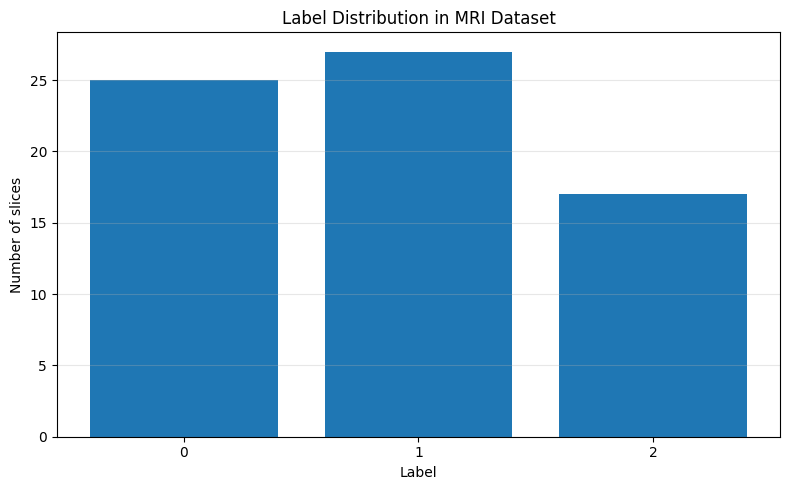

Label 0: 25 samples
Label 1: 27 samples
Label 2: 17 samples
Training Set Label Distribution:


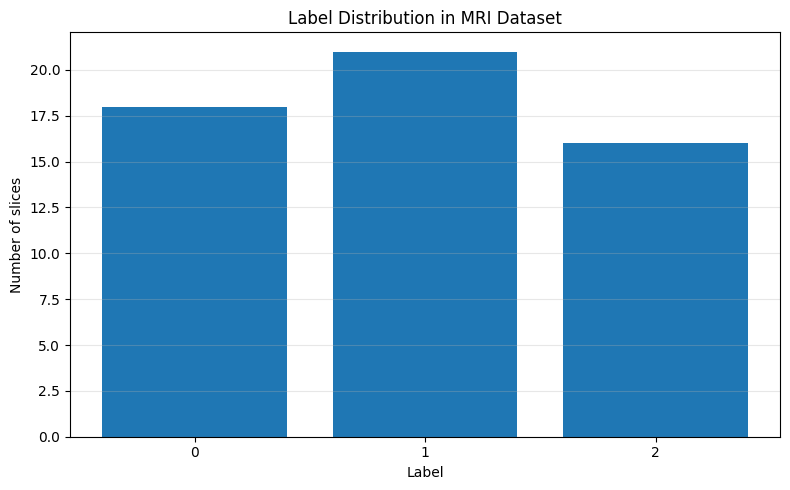

Label 0: 18 samples
Label 1: 21 samples
Label 2: 16 samples
Validation Set Label Distribution:


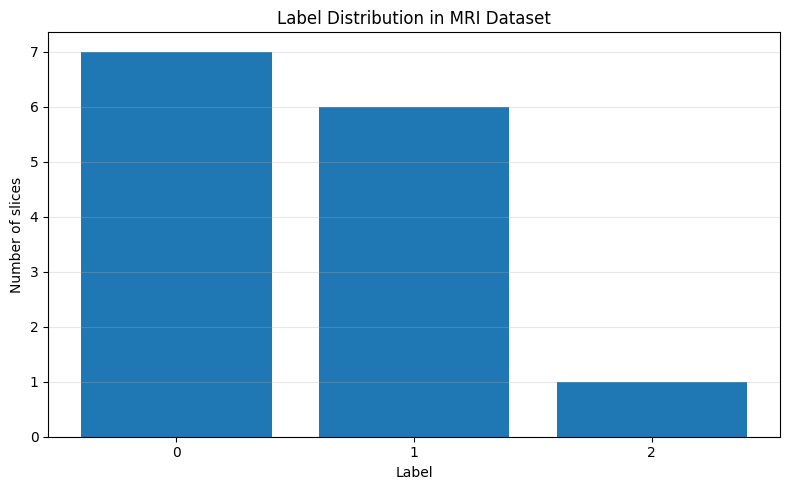

Label 0: 7 samples
Label 1: 6 samples
Label 2: 1 samples


In [30]:
def plot_label_distribution(dataset):
    labels = []
    for _, label in dataset:
        # handle torch tensor labels
        if isinstance(label, torch.Tensor):
            label = label.item()
        labels.append(label)
    label_counts = Counter(labels)
    # sort by label index
    labels_sorted = sorted(label_counts.keys())
    counts_sorted = [label_counts[l] for l in labels_sorted]
    plt.figure(figsize=(8, 5))
    plt.bar(labels_sorted, counts_sorted)
    plt.xlabel("Label")
    plt.ylabel("Number of slices")
    plt.title("Label Distribution in MRI Dataset")
    plt.xticks(labels_sorted)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
    # also print counts
    for l in labels_sorted:
        print(f"Label {l}: {label_counts[l]} samples")
# Plot label distribution for the entire dataset, training set, and validation set
print("Overall Dataset Label Distribution:")
plot_label_distribution(dataset)
print("Training Set Label Distribution:")
plot_label_distribution(train_dataset)
print("Validation Set Label Distribution:")
plot_label_distribution(val_dataset)

In [14]:
wandb.login()

wandb: Currently logged in as: baymaxnguyen306 (baymaxnguyen306-ho-chi-minh-city-university-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [44]:

class TrainerWB:
    def __init__(
        self,
        config,
        train_loader,
        val_loader,
        model,
        class_weights=None,
    ):
        self.config = config
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.epochs = config["epoch"]
        self.lr = config["lr"]

        # Regularization-related configs
        self.weight_decay = config.get("weight_decay", 1e-4)
        self.patience = config.get("patience", 10)
        self.label_smoothing = config.get("label_smoothing", 0.05)
        self.grad_clip = config.get("grad_clip", 1.0)
        
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.model = model.to(self.device)

        # Loss with label smoothing
        if class_weights is not None:
            self.criterion = nn.CrossEntropyLoss(
                weight=class_weights.to(self.device),
                label_smoothing=self.label_smoothing
            )
        else:
            self.criterion = nn.CrossEntropyLoss(
                label_smoothing=self.label_smoothing
            )

        # AdamW already includes decoupled weight decay
        self.optimizer = optim.AdamW(
            self.model.parameters(),
            lr=self.lr,
            weight_decay=self.weight_decay
        )

        # LR scheduler
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer=self.optimizer,
            mode='min',
            factor=0.5,
            patience=5
        )

        # Early stopping / best model
        self.best_macro_f1 = -1.0
        self.best_val_loss = float("inf")
        self.best_epoch = 0
        self.epochs_no_improve = 0
        self.best_state_dict = None
    
    def train_one_epoch(self):
        self.model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        loop = tqdm(self.train_loader, desc="Training", leave=False)

        for images, labels in loop:
            images = images.to(self.device, non_blocking=True)
            labels = labels.to(self.device, non_blocking=True)

            self.optimizer.zero_grad()

            outputs = self.model(images)
            loss = self.criterion(outputs, labels)

            loss.backward()

            # Gradient clipping
            if self.grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=self.grad_clip)

            self.optimizer.step()

            batch_size = images.size(0)
            running_loss += loss.item() * batch_size

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += batch_size

            loop.set_postfix(
                loss=running_loss / total,
                acc=correct / total,
                lr=self.optimizer.param_groups[0]["lr"]
            )

        train_loss = running_loss / total
        train_acc = correct / total
        return train_loss, train_acc

    def validate_one_epoch(self):
        self.model.eval()

        running_loss = 0.0
        correct = 0
        total = 0

        all_preds = []
        all_labels = []

        with torch.no_grad():
            for images, labels in self.val_loader:
                images = images.to(self.device, non_blocking=True)
                labels = labels.to(self.device, non_blocking=True)

                outputs = self.model(images)
                loss = self.criterion(outputs, labels)

                batch_size = images.size(0)
                running_loss += loss.item() * batch_size

                preds = outputs.argmax(dim=1)
                correct += (preds == labels).sum().item()
                total += batch_size

                all_preds.extend(preds.cpu().numpy().tolist())
                all_labels.extend(labels.cpu().numpy().tolist())

        val_loss = running_loss / total
        val_acc = correct / total

        macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
        weighted_f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
        balanced_acc = balanced_accuracy_score(all_labels, all_preds)
        cm = confusion_matrix(all_labels, all_preds)

        return val_loss, val_acc, macro_f1, weighted_f1, balanced_acc, cm

    def save_best_model(self, save_path="best_model.pth"):
        if self.best_state_dict is not None:
            torch.save(self.best_state_dict, save_path)

    def fit(self, print_every=1, cm_every=5):
        print(f"Using device: {self.device}")

        for epoch in range(1, self.epochs + 1):
            train_loss, train_acc = self.train_one_epoch()
            val_loss, val_acc, macro_f1, weighted_f1, balanced_acc, cm = self.validate_one_epoch()

            self.scheduler.step(val_loss)
            current_lr = self.optimizer.param_groups[0]["lr"]

            improved = False
            if macro_f1 > self.best_macro_f1:
                self.best_macro_f1 = macro_f1
                self.best_val_loss = val_loss
                self.best_epoch = epoch
                self.best_state_dict = copy.deepcopy(self.model.state_dict())
                self.epochs_no_improve = 0
                improved = True
            else:
                self.epochs_no_improve += 1

            if epoch % print_every == 0:
                print(f"\nEpoch [{epoch}/{self.epochs}]")
                print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
                print(f"Val Loss:   {val_loss:.4f}, Val Acc:   {val_acc:.4f}")
                print(f"Macro F1:   {macro_f1:.4f}")
                print(f"Weighted F1:{weighted_f1:.4f}")
                print(f"Balanced Acc: {balanced_acc:.4f}")
                print(f"LR: {current_lr:.6f}")
                print(f"Best Macro F1 so far: {self.best_macro_f1:.4f} at epoch {self.best_epoch}")

            if epoch % cm_every == 0:
                print("\nConfusion Matrix:")
                print(cm)

            wandb.log({
                "epoch": epoch,
                "lr": current_lr,
                "train_loss": train_loss,
                "train_accuracy": train_acc,
                "val_loss": val_loss,
                "val_accuracy": val_acc,
                "val_macro_f1": macro_f1,
                "val_weighted_f1": weighted_f1,
                "val_balanced_accuracy": balanced_acc,
                "best_macro_f1": self.best_macro_f1,
                "improved": int(improved),
                "label_smoothing": self.label_smoothing,
                "grad_clip": self.grad_clip,
                "weight_decay": self.weight_decay
            })

            if self.epochs_no_improve >= self.patience:
                print(f"\nEarly stopping triggered at epoch {epoch}.")
                break

        print(f"\nTraining complete.")
        print(f"Best Macro F1: {self.best_macro_f1:.4f} at epoch {self.best_epoch}")

In [45]:
class Sampler():
    def __init__(self,dataset:MRI_data):
        self.dataset=dataset
        self.labels=self.Get_label_array()
    def Get_classes_count(self):
        class_counts = Counter(int(train_dataset[i][1]) for i in range(len(train_dataset)))
        counts_list = [class_counts[k] for k in sorted(class_counts.keys())]
        return counts_list
    def Get_label_array(self):
        labels=[]
        for _,label in self.dataset:
            if isinstance(label,torch.Tensor):
                label=label.item()
            labels.append(label)
        return labels
    def init_sampler(self):
        class_count = self.Get_classes_count()
        weights = 1.0 / np.array(class_count)
        samples_weight = np.array([weights[int(t)] for t in self.labels])
        sampler = WeightedRandomSampler(samples_weight, num_samples=len(samples_weight))
        return sampler

# if __name__=="__main__":
#     s=Sampler(train_dataset)
#     sampler=s.init_sampler()
    

    


In [46]:
def main():
    with wandb.init(project="ACL_Classification_3D_CNN", reinit=True):
        s=Sampler(train_dataset)
        sampler=s.init_sampler()
        config=wandb.config
        train_loader = DataLoader(train_dataset,batch_size=config.batch_size,sampler=sampler)
        val_loader = DataLoader(val_dataset,batch_size=config.batch_size,shuffle=False)
        trainer = TrainerWB(
            config=wandb.config,
            train_loader=train_loader,
            val_loader=val_loader,
            model=model
        )
        trainer.fit(print_every=5,cm_every=5)

In [ ]:
sweep_id= wandb.sweep(sweep_config, project="ACL_Classification_3D_CNN_352x352")
wandb.agent(sweep_id,  function=main, count=3)

Create sweep with ID: skc5te1e
Sweep URL: https://wandb.ai/baymaxnguyen306-ho-chi-minh-city-university-of-technology/ACL_Classification_3D_CNN_352x352/sweeps/skc5te1e


wandb: Agent Starting Run: c3vhdrfn with config:
wandb: 	batch_size: 4
wandb: 	epoch: 40
wandb: 	lr: 0.001


Using device: cuda



Epoch [5/40]
Train Loss: 1.1096, Train Acc: 0.3106
Val Loss:   1.0623, Val Acc:   0.4118
Macro F1:   0.2171
Weighted F1:0.3639
Balanced Acc: 0.2456
LR: 0.001000
Best Macro F1 so far: 0.3041 at epoch 3

Confusion Matrix:
[[ 0  1  5]
 [ 0 14  5]
 [ 0  9  0]]



Epoch [10/40]
Train Loss: 1.1079, Train Acc: 0.3485
Val Loss:   1.0871, Val Acc:   0.2647
Macro F1:   0.1395
Weighted F1:0.1108
Balanced Acc: 0.3333
LR: 0.001000
Best Macro F1 so far: 0.3041 at epoch 3

Confusion Matrix:
[[ 0  0  6]
 [ 0  0 19]
 [ 0  0  9]]



Early stopping triggered at epoch 13.

Training complete.
Best Macro F1: 0.3041 at epoch 3


best_macro_f1,▁▅███████████
epoch,▁▂▂▃▃▄▅▅▆▆▇▇█
grad_clip,▁▁▁▁▁▁▁▁▁▁▁▁▁
improved,███▁▁▁▁▁▁▁▁▁▁
label_smoothing,▁▁▁▁▁▁▁▁▁▁▁▁▁
lr,██████████▁▁▁
train_accuracy,▆▇▃▃▃▃▅██▅▁▂▃
train_loss,▅▂█▇▄▇▂▃▁▄█▅▆
val_accuracy,▃█▅▁▆▁▃▃▁▃▄▄▄
val_balanced_accuracy,▇▆▅▇▁▇▇▇▇▇▁▁█
+4,...


wandb: Agent Starting Run: 5g4y9yxy with config:
wandb: 	batch_size: 8
wandb: 	epoch: 40
wandb: 	lr: 0.0005


Using device: cuda
